# 이진분류 모델 비교 시각화 (LightGBM vs DeepLearning MLP)

이 노트북은 `new_flight_weather_merged.csv`를 불러와서:
- **LightGBMClassifier** (다운샘플링)  
- **DeepLearning MLP** (OneHot + (옵션) SVD + class_weight)

을 같은 **시간 기준 80/20 split**으로 학습/예측한 뒤,
**리더보드 + ROC/PR Curve + Confusion Matrix + Threshold Sweep** 비교 시각화를 생성합니다.

> ✅ 기존 파일들 기준으로 맞춰둠:
> - `3-1.이진분류_지연에 맞춰_다운사이징_코드화.ipynb` (LGBM)
> - `4.이진분류_DeepLearning_MLP.ipynb` (DL)

---
## 사용법
1) 아래 `csv_path`만 본인 환경에 맞게 수정  
2) 위에서 아래로 순서대로 실행


In [1]:
# =========================
# ✅ 0) 환경 설정
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

np.random.seed(42)

# ✅ 경로만 본인 환경에 맞게 수정하세요
csv_path = r"data/new_flight_weather_merged.csv"  # 예: r"C:/ai/1month/data/new_flight_weather_merged.csv"


In [2]:
# =========================
# 1) 데이터 로드 + 기본 타깃 준비
# =========================
df = pd.read_csv(csv_path)
print("✅ CSV 로드:", len(df), "rows |", df.shape[1], "cols")

# is_delay 없으면 상태로 생성
if "is_delay" not in df.columns:
    if "상태" not in df.columns:
        raise KeyError("❌ 'is_delay'도 없고 '상태'도 없습니다.")
    df["is_delay"] = (df["상태"] == "지연").astype(int)

# departure_datetime 필수
if "departure_datetime" not in df.columns:
    raise KeyError("❌ 'departure_datetime' 컬럼이 없습니다.")
df["departure_datetime"] = pd.to_datetime(df["departure_datetime"], errors="coerce")
df = df[df["departure_datetime"].notna()].copy()

# 시간 파생(없으면 생성)
if "dep_hour" not in df.columns:
    df["dep_hour"] = df["departure_datetime"].dt.hour
if "dep_weekday" not in df.columns:
    df["dep_weekday"] = df["departure_datetime"].dt.weekday
if "is_weekend" not in df.columns:
    df["is_weekend"] = df["dep_weekday"].isin([5, 6]).astype(int)

# 도착지 -> arrival_code 코드화 (✅ num_cols로 쓸 예정: int 고정)
if "arrival_code" in df.columns:
    df["arrival_code"] = (
        pd.to_numeric(df["arrival_code"], errors="coerce")
          .fillna(-1)
          .astype(int)
    )
elif "도착지" in df.columns:
    tmp = pd.to_numeric(df["도착지"], errors="coerce")
    if tmp.notna().mean() > 0.7:
        df["arrival_code"] = tmp.fillna(-1).astype(int)
    else:
        df["arrival_code"] = df["도착지"].astype("category").cat.codes.astype(int)
else:
    df["arrival_code"] = -1

print("✅ is_delay 분포")
display(df["is_delay"].value_counts(dropna=False).to_frame("count"))

C:\Users\Admin\AppData\Local\Temp\ipykernel_7880\296914219.py:4: DtypeWarning: Columns (31,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


✅ CSV 로드: 2836872 rows | 55 cols
✅ is_delay 분포


,count
0,2354459
1,482413


In [3]:
# =========================
# 2) Feature 정의 + 시간 기준 80/20 split
# =========================
num_cols = ["기온(°C)", "풍속_ms", "dep_hour", "dep_weekday", "is_weekend", "arrival_code"]
cat_cols = ["항공사", "출발지", "flight_type"]

num_cols = [c for c in num_cols if c in df.columns]
cat_cols = [c for c in cat_cols if c in df.columns]
X_cols = num_cols + cat_cols

if not X_cols:
    raise ValueError("❌ X_cols가 비었습니다. 컬럼명이 CSV와 맞는지 확인하세요.")

df = df.sort_values("departure_datetime")
split_date = df["departure_datetime"].quantile(0.8)

train_df = df[df["departure_datetime"] <= split_date]
test_df  = df[df["departure_datetime"] > split_date]

X_train = train_df[X_cols].copy()
y_train = train_df["is_delay"].astype(int).copy()
X_test  = test_df[X_cols].copy()
y_test  = test_df["is_delay"].astype(int).copy()

print("✅ Split")
print("Train:", len(train_df), "| Test:", len(test_df))
print("Train positive rate:", y_train.mean())
print("Test  positive rate:", y_test.mean())

print("✅ num_cols:", num_cols)
print("✅ cat_cols:", cat_cols)

✅ Split
Train: 2269498 | Test: 567374
Train positive rate: 0.14812438697897068
Test  positive rate: 0.2577576695442512
✅ num_cols: ['기온(°C)', '풍속_ms', 'dep_hour', 'dep_weekday', 'is_weekend', 'arrival_code']
✅ cat_cols: ['항공사', '출발지', 'flight_type']


## 3) LightGBM (Downsampling) 학습/예측

기존 `3-1` 파일 방식 그대로:
- Train에서 0클래스를 1클래스 개수로 **다운샘플링**
- `categorical_feature=cat_cols` 사용


In [4]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

# LightGBM용 category 변환
X_train_lgb = X_train.copy()
X_test_lgb  = X_test.copy()
for c in cat_cols:
    X_train_lgb[c] = X_train_lgb[c].astype("category")
    X_test_lgb[c]  = X_test_lgb[c].astype("category")

# 다운샘플링(Train만)
train_0_idx = y_train[y_train == 0].index
train_1_idx = y_train[y_train == 1].index

if len(train_1_idx) == 0:
    raise ValueError("❌ Train에 양성(1) 샘플이 없습니다. 데이터 분리를 확인하세요.")

down_0_idx = np.random.choice(train_0_idx, size=len(train_1_idx), replace=False)
keep_idx = np.concatenate([down_0_idx, train_1_idx])

X_train_down = X_train_lgb.loc[keep_idx].sample(frac=1, random_state=42)
y_train_down = y_train.loc[keep_idx].loc[X_train_down.index]

print("✅ Downsampling 결과")
print(y_train_down.value_counts())

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    metric="aucpr",
    random_state=42,
    n_jobs=-1
)

lgbm.fit(X_train_down, y_train_down, categorical_feature=cat_cols)
y_prob_lgbm = lgbm.predict_proba(X_test_lgb)[:, 1]

print("✅ LGBM ROC-AUC:", roc_auc_score(y_test, y_prob_lgbm))
print("✅ LGBM PR-AUC :", average_precision_score(y_test, y_prob_lgbm))


✅ Downsampling 결과
0    336168
1    336168
Name: is_delay, dtype: int64
[LightGBM] [Info] Number of positive: 336168, number of negative: 336168
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013532 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 554
[LightGBM] [Info] Number of data points in the train set: 672336, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
✅ LGBM ROC-AUC: 0.7011042182696267
✅ LGBM PR-AUC : 0.44411483845246186


## 4) DeepLearning MLP 학습/예측

기존 `4.이진분류_DeepLearning_MLP.ipynb` 방식 그대로:
- ColumnTransformer (num: median impute, cat: onehot)
- (옵션) 특성이 너무 많으면 SVD로 축소
- class_weight = balanced


In [5]:
import tensorflow as tf

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import TruncatedSVD
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(42)

# 전처리 (DL 원본 로직)
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="UNKNOWN")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

X_train_pp = preprocessor.fit_transform(X_train)
X_test_pp  = preprocessor.transform(X_test)

USE_SVD_IF_WIDE = True
SVD_THRESHOLD = 20000
SVD_COMPONENTS = 512

if USE_SVD_IF_WIDE and X_train_pp.shape[1] > SVD_THRESHOLD:
    print(f"[INFO] 특성 {X_train_pp.shape[1]}개 -> TruncatedSVD({SVD_COMPONENTS})로 축소")
    svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=42)
    X_train_pp = svd.fit_transform(X_train_pp)
    X_test_pp  = svd.transform(X_test_pp)
else:
    if hasattr(X_train_pp, "toarray"):
        X_train_pp = X_train_pp.toarray()
        X_test_pp  = X_test_pp.toarray()

X_train_pp = X_train_pp.astype(np.float32)
X_test_pp  = X_test_pp.astype(np.float32)

y_train_np = y_train.values.astype(np.int32)
y_test_np  = y_test.values.astype(np.int32)

# class_weight
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_np)
class_weight = {0: float(weights[0]), 1: float(weights[1])}
print("✅ class_weight:", class_weight)

# 모델
input_dim = X_train_pp.shape[1]
dl_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

dl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.BinaryAccuracy(name="acc"),
    ],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=4, min_lr=1e-6),
]

history = dl_model.fit(
    X_train_pp, y_train_np,
    validation_data=(X_test_pp, y_test_np),
    epochs=200,
    batch_size=256,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

y_prob_dl = dl_model.predict(X_test_pp).ravel()


✅ class_weight: {0: 0.5869401498968102, 1: 3.3755413959686824}
Epoch 1/200
8866/8866 [==============================] - 31s 3ms/step - loss: 0.6429 - auc: 0.6728 - precision: 0.2125 - recall: 0.7040 - acc: 0.5696 - val_loss: 0.6445 - val_auc: 0.6734 - val_precision: 0.3497 - val_recall: 0.7447 - val_acc: 0.5772 - lr: 0.0010
Epoch 2/200
8866/8866 [==============================] - 30s 3ms/step - loss: 0.6309 - auc: 0.6904 - precision: 0.2205 - recall: 0.7169 - acc: 0.5826 - val_loss: 0.6230 - val_auc: 0.6759 - val_precision: 0.3610 - val_recall: 0.6759 - val_acc: 0.6081 - lr: 0.0010
Epoch 3/200
8866/8866 [==============================] - 30s 3ms/step - loss: 0.6265 - auc: 0.6967 - precision: 0.2238 - recall: 0.7173 - acc: 0.5897 - val_loss: 0.6229 - val_auc: 0.6703 - val_precision: 0.3625 - val_recall: 0.6159 - val_acc: 0.6218 - lr: 0.0010
Epoch 4/200
8866/8866 [==============================] - 29s 3ms/step - loss: 0.6231 - auc: 0.7018 - precision: 0.2270 - recall: 0.7163 - acc: 0.596

## 5) 비교 리더보드 + 시각화

,model,ROC_AUC,PR_AUC,ACC,PREC,RECALL,F1
0,LGBM,0.701104,0.444115,0.641076,0.382444,0.638436,0.478344
1,DL_MLP,0.694857,0.428771,0.639222,0.379946,0.632452,0.474710


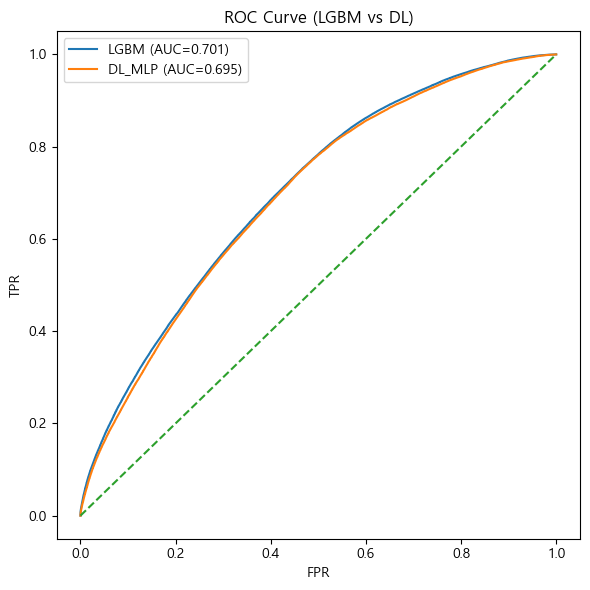

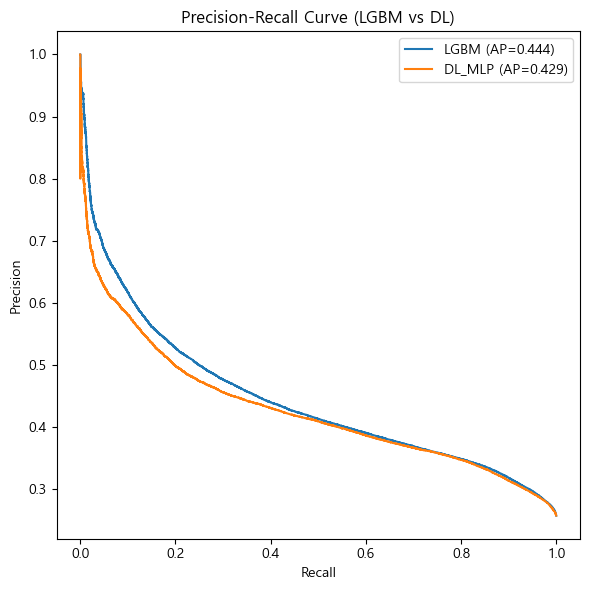

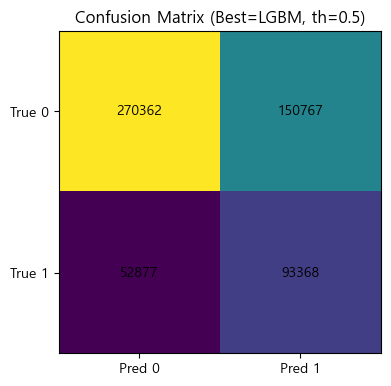

In [6]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve, confusion_matrix
)

probs = {
    "LGBM": y_prob_lgbm,
    "DL_MLP": y_prob_dl
}

TH = 0.5

rows = []
for name, p in probs.items():
    pred = (p >= TH).astype(int)
    rows.append([
        name,
        roc_auc_score(y_test, p),
        average_precision_score(y_test, p),
        accuracy_score(y_test, pred),
        precision_score(y_test, pred, zero_division=0),
        recall_score(y_test, pred, zero_division=0),
        f1_score(y_test, pred, zero_division=0),
    ])

leaderboard = pd.DataFrame(rows, columns=["model","ROC_AUC","PR_AUC","ACC","PREC","RECALL","F1"])\
    .sort_values(["ROC_AUC","PR_AUC","F1"], ascending=False).reset_index(drop=True)

display(leaderboard)

# ---- ROC Curve
plt.figure(figsize=(6,6))
for name, p in probs.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test,p):.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC Curve (LGBM vs DL)")
plt.legend()
plt.tight_layout()
plt.show()

# ---- PR Curve
plt.figure(figsize=(6,6))
for name, p in probs.items():
    prec, rec, _ = precision_recall_curve(y_test, p)
    ap = average_precision_score(y_test, p)
    plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve (LGBM vs DL)")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Confusion Matrix (best model by ROC_AUC)
best = leaderboard.iloc[0]["model"]
pbest = probs[best]
yhat = (pbest >= TH).astype(int)
cm = confusion_matrix(y_test, yhat)

plt.figure(figsize=(4,4))
plt.imshow(cm)
plt.title(f"Confusion Matrix (Best={best}, th={TH})")
plt.xticks([0,1], ["Pred 0","Pred 1"])
plt.yticks([0,1], ["True 0","True 1"])
for (i,j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")
plt.tight_layout()
plt.show()


,model,th,precision,recall,f1
7,LGBM,0.40,0.346949,0.809929,0.485797
27,DL_MLP,0.45,0.361141,0.736114,0.484557


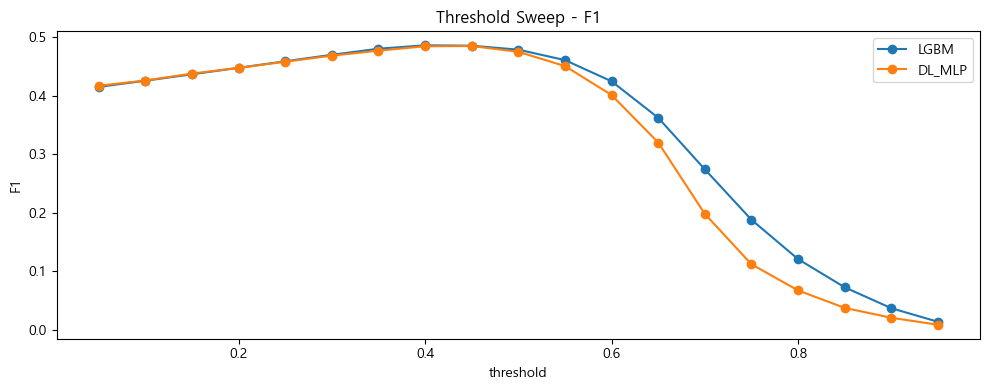

In [7]:
# =========================
# 6) Threshold Sweep (F1 최대 기준)
# =========================
thresholds = np.linspace(0.05, 0.95, 19)

sweep_rows = []
for name, p in probs.items():
    for th in thresholds:
        pred = (p >= th).astype(int)
        sweep_rows.append([name, th,
                           precision_score(y_test, pred, zero_division=0),
                           recall_score(y_test, pred, zero_division=0),
                           f1_score(y_test, pred, zero_division=0)])

sweep_df = pd.DataFrame(sweep_rows, columns=["model","th","precision","recall","f1"])
best_th = sweep_df.loc[sweep_df.groupby("model")["f1"].idxmax()].sort_values("f1", ascending=False)
display(best_th)

# 시각화
plt.figure(figsize=(10,4))
for name in probs.keys():
    sub = sweep_df[sweep_df["model"] == name].sort_values("th")
    plt.plot(sub["th"], sub["f1"], marker="o", label=name)
plt.xlabel("threshold")
plt.ylabel("F1")
plt.title("Threshold Sweep - F1")
plt.legend()
plt.tight_layout()
plt.show()
